# Big-Stage Closer Index (BSCI)  Simple, Reproducible Pipeline

**Goal:** Identify who “finishes the job” - a round-weighted win rate in **QF/SF/F** for **Singles Main Draw** matches.

1) Load raw data (3rd sheet in both files)
2) Light clean & standardize key fields (rounds, match type, main draw)
3) Make a player-match long table with outcomes
4) Compute BSCI (round-weighted win rate in QF/SF/F) with sample guardrails
5) Export leaderboard + a tidy long file for dashboards

**Inputs (what we have):**
- `match_info_view.xlsx`  3rd sheet: `match_info_view_sample` (Rounds, Winner, Draw types)
- `tourn_rounds_q_view.xlsx`  3rd sheet: `tourn_rounds_q_view_sample` (Official round labels)

**How to run:**  
Place `match_info_view.xlsx` and `tourn_rounds_q_view.xlsx` in the same folder as this notebook, then run all cells top-to-bottom.


> Note: We **don’t** have Tier/Level (GS/1000/500/250), so v1 is **round-weighted only**.


In [1]:
# Step 1 — Setup and load 3rd sheets
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

# File paths (keep simple; place files in the same folder as this notebook)
MATCH_FILE = Path("match_info_view.xlsx")
TOURN_FILE = Path("tourn_rounds_q_view.xlsx")

#  loaded the 3rd sheet (index=2) by name, but also print all sheet names for clarity
def load_third_sheet(xlsx_path: Path):
    xls = pd.ExcelFile(xlsx_path)
    sheet_names = xls.sheet_names
    third_name = sheet_names[2] if len(sheet_names) >= 3 else None
    df = pd.read_excel(xls, sheet_name=third_name) if third_name else None
    return sheet_names, third_name, df

# Load both
m_sheets, m_third, df_match_raw = load_third_sheet(MATCH_FILE)
t_sheets, t_third, df_tourn_raw = load_third_sheet(TOURN_FILE)

print("== Sheet names ==")
print("match_info_view:", m_sheets, " | using ->", m_third)
print("tourn_rounds_q_view:", t_sheets, " | using ->", t_third)

print("\n== Shapes ==")
print("df_match_raw:", df_match_raw.shape if df_match_raw is not None else None)
print("df_tourn_raw:", df_tourn_raw.shape if df_tourn_raw is not None else None)


print("\n== match_info_view (first 5) ==")
display(df_match_raw.head(5))

print("\n== tourn_rounds_q_view (first 5) ==")
display(df_tourn_raw.head(5))


print("\nColumns in match_info_view:")
print(list(df_match_raw.columns))

print("\nColumns in tourn_rounds_q_view:")
print(list(df_tourn_raw.columns))


== Sheet names ==
match_info_view: ['Description', 'match_info_view_schema', 'match_info_view_sample']  | using -> match_info_view_sample
tourn_rounds_q_view: ['Description', 'tourn_rounds_q_view_schema', 'tourn_rounds_q_view_sample']  | using -> tourn_rounds_q_view_sample

== Shapes ==
df_match_raw: (5000, 64)
df_tourn_raw: (5000, 103)

== match_info_view (first 5) ==


,UID,EVENTYEAR,EVENTID,MATCHID,EVENTGENDER,DRAWMATCHTYPE,DRAWLEVELTYPE,ROUNDID,DATESEQ,COURTID,MATCHTIMESTAMP,NUMSETS,SCORESYS,MATCHSTATE,WINNER,SEEDA,SEEDB,ENTRYTYPEA,ENTRYTYPEB,PLAYERNAMEFIRSTA,PLAYERNAMELASTA,PLAYERNAMEFIRSTA2,PLAYERNAMELASTA2,PLAYERNAMEFIRSTB,PLAYERNAMELASTB,PLAYERNAMEFIRSTB2,PLAYERNAMELASTB2,PLAYERIDA,PLAYERIDA2,PLAYERIDB,PLAYERIDB2,PLAYERCOUNTRYA,PLAYERCOUNTRYA2,PLAYERCOUNTRYB,PLAYERCOUNTRYB2,SERVE,MATCHTIMETOTAL,MESSAGE,POINTA,POINTB,SCORESET1A,SCORESET1B,SCORESET2A,SCORESET2B,SCORESET3A,SCORESET3B,SCORESET4A,SCORESET4B,SCORESET5A,SCORESET5B,SCORETBSET1,SCORETBSET2,SCORETBSET3,SCORETBSET4,SCORETBSET5,SCORESTRING,RESULTSTRING,EXCLUDEFLAG,LASTUPDATED,XMLSTRING,PACKETKEYSTROKES,BINPACKETBASE64,JSON,MATCHTIMESTAMPLOCAL
0,NaN,2016,300,LD001,L,D,M,7,0,1,2016-10-22 13:50:36,3,9,F,3.0,8.0,1.0,NaN,NaN,Monica,Niculescu,Patricia Maria,Tig,Kiki,Bertens,Johanna,Larsson,310775,317171,314584,311593,ROU,ROU,NED,SWE,A,01:32,{12|K BERTENS / J LARSSON},0.0,0.0,6.0,4.0,5.0,7.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,"4-6,7-5,1-0(9)",[1]K Bertens / J Larsson d [8]M Niculescu / P ...,False,2016-10-22 13:23:14.607,NaN,<XCUQKWR]Q><XgUQKWRl\><XWUQKWRlq><XPUQKWRse>S...,/zAzMDBMRDAwMU0uIE5JQ1VMRVNDVSAgICAgICAgSy4gQk...,NaN,NaT
1,NaN,2016,300,LD002,L,D,M,6,0,2,2016-10-21 16:20:21,3,9,F,3.0,8.0,8.0,NaN,NaN,Jocelyn,Rae,Anna,Smith,Monica,Niculescu,Patricia Maria,Tig,314919,312799,310775,317171,GBR,GBR,ROU,ROU,A,01:02,{12|M NICULESCU / P TIG},0.0,0.0,6.0,0.0,4.0,6.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,"0-6,6-4,1-0(8)",[8]M Niculescu / P Tig d [8]J Rae / A Smith 0-...,False,2016-10-21 15:22:44.787,NaN,<XCUQKVUEH><XgUQKVUME><XWUQKVUOI><XPUQKVUUV>F...,/zAzMDBMRDAwMkouIFJBRSAgICAgICAgICAgICAgTS4gTk...,NaN,NaT
2,NaN,2016,300,LD003,L,D,M,6,0,2,2016-10-21 15:12:00,2,9,F,3.0,8.0,1.0,NaN,NaN,Madison,Brengle,Nicola,Geuer,Kiki,Bertens,Johanna,Larsson,312328,313443,314584,311593,USA,GER,NED,SWE,B,00:50,{12|K BERTENS / J LARSSON},0.0,0.0,2.0,6.0,2.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"6-2,6-2",[1]K Bertens / J Larsson d [8]M Brengle / N Ge...,False,2016-10-21 14:02:56.780,NaN,<XCUQKVS{C><XgUQKVTDF><XWUQKVTEr><XPUQKVTMA>S...,/zAzMDBMRDAwM00uIEJSRU5HTEUgICAgICAgICAgSy4gQk...,NaN,NaT
3,NaN,2016,300,LD004,L,D,M,1,0,2,2016-10-20 10:50:24,2,9,F,0.0,8.0,8.0,NaN,NaN,Jocelyn,Rae,Anna,Smith,Viktorija,Golubic,Nicole,Melichar,314919,312799,316296,316713,GBR,GBR,SUI,USA,A,00:49,NaN,0.0,0.0,6.0,1.0,5.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"6-1,5-4",NaN,False,2016-10-20 09:39:50.423,NaN,<XCUQKUOgC><XgUQKUOlO><XWUQKUOl[><XPUQKUOsY>V...,/zAzMDBMRDAwNEouIFJBRSAgICAgICAgICAgICAgVi4gR0...,NaN,NaT
4,NaN,2016,300,LD005,L,D,M,1,0,2,2016-10-20 15:27:59,2,9,F,2.0,8.0,8.0,NaN,NaN,Monica,Niculescu,Patricia Maria,Tig,Ashley,Weinhold,Caitlin,Whoriskey,310775,317171,312213,312052,ROU,ROU,USA,USA,A,01:10,{12|M NICULESCU / P TIG},0.0,0.0,6.0,1.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"6-1,6-4",[8]M Niculescu / P Tig d [8]A Weinhold / C Who...,False,2016-10-20 14:38:11.593,NaN,<XCUQKUTKc><XgUQKUTSi><XWUQKUTU{><XPUQKUT\|>S...,/zAzMDBMRDAwNU0uIE5JQ1VMRVNDVSAgICAgICAgQS4gV0...,NaN,NaT



== tourn_rounds_q_view (first 5) ==


,UID,TOURN_NBR,TOURN_YEAR,TOURN_ROUND,TOURN_MATCH,QPM_FLAG,S_D_FLAG,WINNER,REASON_CODE,PLAYER_1,PLAYER_2,PLAYER_3,PLAYER_4,RANK_1,RANK_2,RANK_CODE_1,RANK_CODE_2,SEED_1,SEED_2,SET_1_1,SET_1_2,SET_2_1,SET_2_2,SET_3_1,SET_3_2,SET_4_1,SET_4_2,SET_5_1,SET_5_2,TIE_1_1,TIE_1_2,TIE_2_1,TIE_2_2,TIE_3_1,TIE_3_2,TIE_4_1,TIE_4_2,TIE_5_1,TIE_5_2,POINTS_1,POINTS_2,POINTS_BONUS_1,POINTS_BONUS_2,POINTS_CHAMP_1,POINTS_CHAMP_2,TEAM_NAME_1,TEAM_NAME_2,ENTRY_DATE,ENTRY_BY,UPDATE_DATE,UPDATE_BY,SCORES,DRAW_1,DRAW_2,COMMENT,ENTRY_TYPE_1,ENTRY_TYPE_2,SPC_RANK_1,SPC_RANK_2,ENTRY_RANK_1,ENTRY_RANK_2,ROUND_NAME,CODE_PAY_POINTS,CODE_PAY_PRIZE,AGE_1,AGE_2,AGE_3,AGE_4,MATCH_MINS,MATCH_FORM,ACES_1,DBL_FAULTS_1,FIRST_SERVES_PLAY_1,FIRST_SERVES_WON_1,SECOND_SERVES_PLAY_1,SECOND_SERVES_WON_1,SERVICE_GAMES_1,BPOINT_CHANCES_1,BPOINT_CONVERTED_1,FIRST_RET_CHANCES_1,FIRST_RET_WON_1,SECOND_RET_CHANCES_1,SECOND_RET_WON_1,BPOINT_FACED_1,BPOINT_LOST_1,RET_GAMES_PLAY_1,ACES_2,DBL_FAULTS_2,FIRST_SERVES_PLAY_2,FIRST_SERVES_WON_2,SECOND_SERVES_PLAY_2,SECOND_SERVES_WON_2,SERVICE_GAMES_2,BPOINT_CHANCES_2,BPOINT_CONVERTED_2,FIRST_RET_CHANCES_2,FIRST_RET_WON_2,SECOND_RET_CHANCES_2,SECOND_RET_WON_2,BPOINT_FACED_2,BPOINT_LOST_2,RET_GAMES_PLAY_2,TOURN_TYPE
0,NaN,103,1989,1,1,M,D,1,B,10001,BYE,40084.0,NaN,579.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,"AALLONEN, ANNE / DAHLMAN, NANNE",BYE,NaT,NaN,NaT,NaN,NaN,1,2,NaN,NaN,NaN,0.0,0.0,0.0,0.0,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,248,1990,1,1,M,D,1,B,10001,BYE,50007.0,NaN,304.0,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,"AALLONEN, ANNE / EKSTRAND, MARIA",BYE,NaT,NaN,NaT,NaN,NaN,1,2,NaN,NaN,NaN,0.0,0.0,0.0,0.0,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,251,1988,1,1,M,D,1,B,10001,BYE,40004.0,NaN,444.0,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,"AALLONEN, ANNE / DAHLSTROM, HELENA",BYE,NaT,NaN,NaT,NaN,NaN,1,2,NaN,NaN,NaN,0.0,0.0,0.0,0.0,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,228,1988,1,3,M,D,1,B,10001,BYE,40084.0,NaN,0.0,0.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,"AALLONEN, ANNE / DAHLMAN, NANNE",BYE,NaT,NaN,NaT,NaN,NaN,5,6,NaN,NaN,NaN,0.0,0.0,0.0,0.0,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,176,1989,1,8,M,D,1,B,10001,BYE,190026.0,NaN,258.0,0.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,"AALLONEN, ANNE / SCHILDER, SIMONE",BYE,NaT,NaN,NaT,NaN,NaN,16,15,NaN,NaN,NaN,0.0,0.0,0.0,0.0,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Columns in match_info_view:
['UID', 'EVENTYEAR', 'EVENTID', 'MATCHID', 'EVENTGENDER', 'DRAWMATCHTYPE', 'DRAWLEVELTYPE', 'ROUNDID', 'DATESEQ', 'COURTID', 'MATCHTIMESTAMP', 'NUMSETS', 'SCORESYS', 'MATCHSTATE', 'WINNER', 'SEEDA', 'SEEDB', 'ENTRYTYPEA', 'ENTRYTYPEB', 'PLAYERNAMEFIRSTA', 'PLAYERNAMELASTA', 'PLAYERNAMEFIRSTA2', 'PLAYERNAMELASTA2', 'PLAYERNAMEFIRSTB', 'PLAYERNAMELASTB', 'PLAYERNAMEFIRSTB2', 'PLAYERNAMELASTB2', 'PLAYERIDA', 'PLAYERIDA2', 'PLAYERIDB', 'PLAYERIDB2', 'PLAYERCOUNTRYA', 'PLAYERCOUNTRYA2', 'PLAYERCOUNTRYB', 'PLAYERCOUNTRYB2', 'SERVE', 'MATCHTIMETOTAL', 'MESSAGE', 'POINTA', 'POINTB', 'SCORESET1A', 'SCORESET1B', 'SCORESET2A', 'SCORESET2B', 'SCORESET3A', 'SCORESET3B', 'SCORESET4A', 'SCORESET4B', 'SCORESET5A', 'SCORESET5B', 'SCORETBSET1', 'SCORETBSET2', 'SCORETBSET3', 'SCORETBSET4', 'SCORETBSET5', 'SCORESTRING', 'RESULTSTRING', 'EXCLUDEFLAG', 'LASTUPDATED', 'XMLSTRING', 'PACKETKEYSTROKES', 'BINPACKETBASE64', 'JSON', 'MATCHTIMESTAMPLOCAL']

Columns in tourn_rounds_q_vie

## Minimal cleaning & standardization


- Kept only the few columns we need
- Create simple **Singles** and **Main-Draw** flags
- Standardize round into crisp labels we’ll use later (QF, SF, F)
- Quick sanity checks (value counts)

> Note: We’ll compute the index only on **Singles Main Draw** and only in **QF/SF/F**.


In [2]:
# Pick the minimal columns we need
use_cols = [
    "EVENTYEAR","EVENTID","MATCHID",
    "DRAWMATCHTYPE","DRAWLEVELTYPE","ROUNDID",
    "WINNER",
    "PLAYERNAMEFIRSTA","PLAYERNAMELASTA",
    "PLAYERNAMEFIRSTB","PLAYERNAMELASTB",
]

dfm = df_match_raw[use_cols].copy()

# Flags: Singles / Main draw
dfm["IS_SINGLES"] = dfm["DRAWMATCHTYPE"].astype(str).str.upper().eq("S")
dfm["IS_MAIN"]    = dfm["DRAWLEVELTYPE"].astype(str).str.upper().eq("M")

# Helper: build full names (First + Last) with simple null handling
def full_name(first, last):
    f = ("" if pd.isna(first) else str(first).strip())
    l = ("" if pd.isna(last)  else str(last).strip())
    nm = " ".join([f,l]).strip()
    return nm if nm else None

dfm["PLAYER_A"] = [full_name(f,l) for f,l in zip(dfm["PLAYERNAMEFIRSTA"], dfm["PLAYERNAMELASTA"])]
dfm["PLAYER_B"] = [full_name(f,l) for f,l in zip(dfm["PLAYERNAMEFIRSTB"], dfm["PLAYERNAMELASTB"])]

# Standardize round labels we care about: QF / SF / F
# Your ROUNDID has values like 'Q','S','F','R32','6','7', etc.
# We'll map the obvious ones and leave others as-is (we'll filter later).
def std_round(x):
    s = str(x).strip().upper()
    if s in {"Q","QF"}:  return "QF"
    if s in {"S","SF"}:  return "SF"
    if s in {"F"}:       return "F"
    # If it's something else (R32, numbers, qualifiers), keep as-is for now
    return s

dfm["ROUND_STD"] = dfm["ROUNDID"].apply(std_round)

# --- Sanity checks ---
print("Singles vs Doubles:")
print(dfm["IS_SINGLES"].value_counts(dropna=False))

print("\nMain vs Qualifying:")
print(dfm["IS_MAIN"].value_counts(dropna=False))

print("\nTop ROUNDID values:")
print(dfm["ROUNDID"].astype(str).str.upper().value_counts().head(15))

print("\nTop ROUND_STD values:")
print(dfm["ROUND_STD"].value_counts().head(10))

# Peek after we *would* filter to Singles Main Draw (we'll filter in next step)
display(dfm.head(8))


Singles vs Doubles:
IS_SINGLES
True     3900
False    1100
Name: count, dtype: int64

Main vs Qualifying:
IS_MAIN
True     3605
False    1395
Name: count, dtype: int64

Top ROUNDID values:
ROUNDID
1     2507
2     1223
Q      419
3      225
S      212
F      106
4       78
Q1      68
6       50
5       43
7       31
Q4      22
Q2      16
Name: count, dtype: int64

Top ROUND_STD values:
ROUND_STD
1     2507
2     1223
QF     419
3      225
SF     212
F      106
4       78
Q1      68
6       50
5       43
Name: count, dtype: int64


,EVENTYEAR,EVENTID,MATCHID,DRAWMATCHTYPE,DRAWLEVELTYPE,ROUNDID,WINNER,PLAYERNAMEFIRSTA,PLAYERNAMELASTA,PLAYERNAMEFIRSTB,PLAYERNAMELASTB,IS_SINGLES,IS_MAIN,PLAYER_A,PLAYER_B,ROUND_STD
0,2016,300,LD001,D,M,7,3.0,Monica,Niculescu,Kiki,Bertens,False,True,Monica Niculescu,Kiki Bertens,7
1,2016,300,LD002,D,M,6,3.0,Jocelyn,Rae,Monica,Niculescu,False,True,Jocelyn Rae,Monica Niculescu,6
2,2016,300,LD003,D,M,6,3.0,Madison,Brengle,Kiki,Bertens,False,True,Madison Brengle,Kiki Bertens,6
3,2016,300,LD004,D,M,1,0.0,Jocelyn,Rae,Viktorija,Golubic,False,True,Jocelyn Rae,Viktorija Golubic,1
4,2016,300,LD005,D,M,1,2.0,Monica,Niculescu,Ashley,Weinhold,False,True,Monica Niculescu,Ashley Weinhold,1
5,2016,300,LD006,D,M,1,0.0,Annika,Beck,Madison,Brengle,False,True,Annika Beck,Madison Brengle,1
6,2016,300,LD007,D,M,1,0.0,Kirsten,Flipkens,Kiki,Bertens,False,True,Kirsten Flipkens,Kiki Bertens,1
7,2016,300,LD008,D,M,1,0.0,Raquel,Atawo,Jocelyn,Rae,False,True,Raquel Atawo,Jocelyn Rae,1


## Player-long table (clean slice for BSCI)
From the cleaned match table (`dfm`), we:

- Filter to **Singles Main Draw** matches.
- Keep only **QF/SF/F** rounds.
- Expand each match into two rows (one per player).
- Add `IS_WIN` = 1/0 per player per match.

This produces `df_long`, which is the core input for the BSCI calculation.

**Assumption for WINNER column**
- For singles, `WINNER` is usually **1 = Player A**, **2 = Player B**.
- If a row’s `WINNER` isn’t 1 or 2 (rare), we’ll drop that row from BSCI to avoid bad labels.


In [3]:
# 3.1 Filter to Singles Main Draw first
df_sm = dfm[(dfm["IS_SINGLES"]) & (dfm["IS_MAIN"])].copy()

# 3.2 Keep only late rounds for BSCI
late_rounds = {"QF","SF","F"}
df_late = df_sm[df_sm["ROUND_STD"].isin(late_rounds)].copy()

print("Rows in Singles+MainDraw:", len(df_sm))
print("Rows in QF/SF/F:", len(df_late))
print("Round breakdown (late only):")
print(df_late["ROUND_STD"].value_counts())

# 3.3 Clean WINNER to numeric and keep only {1,2}
def to_int_or_nan(x):
    try:
        return int(float(x))
    except Exception:
        return None

df_late["WINNER_INT"] = df_late["WINNER"].apply(to_int_or_nan)
df_late = df_late[df_late["WINNER_INT"].isin([1,2])].copy()

# 3.4 Make two rows per match: one for A (win=1 if WINNER_INT==1), one for B (win=1 if WINNER_INT==2)
records = []
for _, r in df_late.iterrows():
    a = r.get("PLAYER_A")
    b = r.get("PLAYER_B")
    if not a or not b:
        continue  # skip if a name is missing

    # Player A row
    records.append({
        "EVENTYEAR": r["EVENTYEAR"],
        "EVENTID": r["EVENTID"],
        "MATCHID": r["MATCHID"],
        "ROUND_STD": r["ROUND_STD"],
        "PLAYER": a,
        "IS_WIN": 1 if r["WINNER_INT"] == 1 else 0
    })
    # Player B row
    records.append({
        "EVENTYEAR": r["EVENTYEAR"],
        "EVENTID": r["EVENTID"],
        "MATCHID": r["MATCHID"],
        "ROUND_STD": r["ROUND_STD"],
        "PLAYER": b,
        "IS_WIN": 1 if r["WINNER_INT"] == 2 else 0
    })

df_long = pd.DataFrame(records)

print("\nPlayer-long shape:", df_long.shape)
print("Sample:")
display(df_long.head(8))

print("\nCheck IS_WIN distribution:")
print(df_long["IS_WIN"].value_counts())

print("\nCheck late-round distribution:")
print(df_long["ROUND_STD"].value_counts())


Rows in Singles+MainDraw: 2508
Rows in QF/SF/F: 371
Round breakdown (late only):
ROUND_STD
QF    211
SF    107
F      53
Name: count, dtype: int64

Player-long shape: (342, 6)
Sample:


,EVENTYEAR,EVENTID,MATCHID,ROUND_STD,PLAYER,IS_WIN
0,2017,300,LS002,SF,Monica Puig,0
1,2017,300,LS002,SF,Elise Mertens,1
2,2017,300,LS004,QF,Monica Puig,0
3,2017,300,LS004,QF,Naomi Broady,1
4,2017,300,LS007,QF,Carina Witthoeft,0
5,2017,300,LS007,QF,Kiki Bertens,1
6,2018,300,LS001,F,Julia Goerges,0
7,2018,300,LS001,F,Belinda Bencic,1



Check IS_WIN distribution:
IS_WIN
0    171
1    171
Name: count, dtype: int64

Check late-round distribution:
ROUND_STD
QF    214
SF     82
F      46
Name: count, dtype: int64


## Compute Big-Stage Closer Index (BSCI)
We aggregate `df_long` by player, apply round weights (QF/SF/F), and compute a weighted win rate for late rounds, plus sample-size flags.


**Definition (v1):**  
BSCI = round-weighted win rate in **QF/SF/F** for **Singles Main Draw**.

- Weights (editable):
  - QF = 1.5
  - SF = 1.7
  - F  = 2.0
- Sample guardrail: require at least `MIN_LATE_MATCHES` (defaults to 6) late-round matches.
- Output: Leaderboard with `PLAYER`, `LateMatches`, `BSCI`, and round splits.


In [4]:
# Round weights (tweakable)
ROUND_W = {"QF": 1.5, "SF": 1.7, "F": 2.0}
MIN_LATE_MATCHES = 6  # change to 8/10 if you want stricter stability

# Apply weights
df_long["W"] = df_long["ROUND_STD"].map(ROUND_W).fillna(1.0)

# Aggregate per player: weighted win rate + counts by round
grp = df_long.groupby("PLAYER", dropna=False)

agg = grp.agg(
    LateMatches = ("IS_WIN", "size"),
    WinsWeighted = ("IS_WIN", lambda s: float((s * df_long.loc[s.index, "W"]).sum())),
    WSum = ("W", "sum"),
)

# Win rate (0..1) then scale to 0..100 for readability
agg["BSCI"] = (agg["WinsWeighted"] / agg["WSum"]).clip(0,1) * 100

# Round splits for context
def round_count(df, r):
    return (df["ROUND_STD"] == r).sum()

split = grp.apply(lambda g: pd.Series({
    "QF_played": round_count(g, "QF"),
    "SF_played": round_count(g, "SF"),
    "F_played":  round_count(g, "F"),
    "QF_wins":   int(((g["ROUND_STD"]=="QF") & (g["IS_WIN"]==1)).sum()),
    "SF_wins":   int(((g["ROUND_STD"]=="SF") & (g["IS_WIN"]==1)).sum()),
    "F_wins":    int(((g["ROUND_STD"]=="F")  & (g["IS_WIN"]==1)).sum()),
})).reset_index()

res = agg.reset_index().merge(split, on="PLAYER", how="left")

# Flag low samples; sort leaderboard
res["LowSampleFlag"] = (res["LateMatches"] < MIN_LATE_MATCHES).astype(int)
leaderboard = res.sort_values(["LowSampleFlag","BSCI","LateMatches"], ascending=[True, False, False]).reset_index(drop=True)

print("Leaderboard (top 15 shown):")
display(leaderboard.head(15)[["PLAYER","LateMatches","BSCI","QF_played","SF_played","F_played","QF_wins","SF_wins","F_wins","LowSampleFlag"]])

print("\nSummary:")
print("Players total:", leaderboard.shape[0])
print("Players meeting sample >=", MIN_LATE_MATCHES, ":", int((leaderboard["LowSampleFlag"]==0).sum()))


Leaderboard (top 15 shown):


C:\Users\saida\AppData\Local\Temp\ipykernel_26520\3035380728.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  split = grp.apply(lambda g: pd.Series({


,PLAYER,LateMatches,BSCI,QF_played,SF_played,F_played,QF_wins,SF_wins,F_wins,LowSampleFlag
0,Elise Mertens,6,84.536082,4,1,1,3,1,1,0
1,Anastasia Pavlyuchenkova,6,63.917526,4,1,1,3,1,0,0
2,Kiki Bertens,6,51.041667,3,3,0,1,2,0,0
3,Maria Sakkari,7,47.826087,5,0,2,1,0,2,0
4,Aryna Sabalenka,10,40.449438,2,4,4,1,1,2,0
5,Dayana Yastremska,6,36.633663,2,3,1,0,1,1,0
6,Ekaterina Alexandrova,6,35.000000,4,0,2,1,0,1,0
7,Jelena Ostapenko,10,21.637427,4,3,3,0,1,1,0
8,Iga Swiatek,6,16.346154,2,2,2,0,1,0,0
9,Danielle Collins,6,0.000000,4,1,1,0,0,0,0



Summary:
Players total: 136
Players meeting sample >= 6 : 10


## Exports — Cleaned outputs for WTA dashboards

We save:
- `bsci_leaderboard.csv` — one row per player (BSCI and counts)
- `bsci_player_long.csv` — one row per player per late-round match


In [5]:
from pathlib import Path

out_dir = Path("bsci_outputs"); out_dir.mkdir(exist_ok=True, parents=True)

leaderboard_path = out_dir / "bsci_leaderboard.csv"
player_long_path = out_dir / "bsci_player_long.csv"

leaderboard.to_csv(leaderboard_path, index=False)
df_long.to_csv(player_long_path, index=False)

print("Saved:", leaderboard_path)
print("Saved:", player_long_path)


Saved: bsci_outputs\bsci_leaderboard.csv
Saved: bsci_outputs\bsci_player_long.csv


## Visual 1 — Top Big-Stage Closers (BSCI)

Bar chart of the top N players by BSCI, with late-round volume and QF/SF/F breakdown to show who consistently performs well on the big stage.


In [19]:
import plotly.express as px
import plotly.graph_objects as go

# A clean, readable color set (you asked for distinct player colors)
PLAYER_COLORS = ["#2E86AB", "#E67E22", "#7D3C98", "#16A085", "#C0392B", "#566573"]


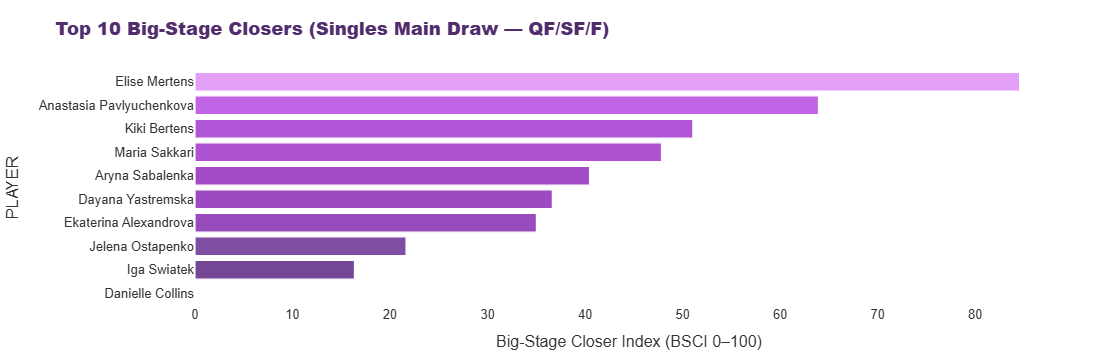

Players meeting sample threshold: 10. Showing: 10.


In [20]:
import plotly.express as px
import plotly.graph_objects as go

# WTA-inspired color palette: purple → magenta → pink gradient
WTA_COLORS = ["#512D6D", "#7E4EA2", "#A64AC9", "#C063E6", "#E39FF6"]

TOP_N_REQUESTED = 20

stable = (
    leaderboard[leaderboard["LowSampleFlag"] == 0]
    .sort_values(["BSCI", "LateMatches"], ascending=[False, False])
)

available = len(stable)
topN = min(TOP_N_REQUESTED, available)
subset = stable.head(topN)

fig = px.bar(
    subset,
    x="BSCI",
    y="PLAYER",
    orientation="h",
    color="BSCI",  # use BSCI for smooth gradient intensity
    color_continuous_scale=WTA_COLORS,
    hover_data={
        "PLAYER": False,
        "LateMatches": True,
        "QF_played": True,
        "SF_played": True,
        "F_played": True,
        "QF_wins": True,
        "SF_wins": True,
        "F_wins": True,
        "BSCI":":.2f"
    },
    title=f"Top {topN} Big-Stage Closers (Singles Main Draw — QF/SF/F)"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Big-Stage Closer Index (BSCI 0–100)",
    coloraxis_showscale=False,  # remove side color bar for cleaner look
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=13, color="#333333"),
    title_font=dict(size=18, color="#512D6D", family="Arial Black"),
    title_x=0.05,
    margin=dict(l=100, r=40, t=70, b=50)
)

fig.update_traces(
    marker_line_color="white",
    marker_line_width=1.2,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "BSCI: %{x:.2f}<br>"
        "Late Matches: %{customdata[0]}<br>"
        "QF/SF/F Wins: %{customdata[4]} / %{customdata[5]} / %{customdata[6]}"
    )
)

fig.show()

print(f"Players meeting sample threshold: {available}. Showing: {topN}.")


## Step 1 — Baselines for “Before vs After”
We’ll build:
- **OverallWin%**: Singles Main-Draw win rate across *all* rounds (baseline).
- **EarlyWin%**: Singles Main-Draw win rate in *non-late* rounds (not QF/SF/F).
- Keep **BSCI** from Step 4.

This lets us show:
- Who looks great on overall win% but **fades under pressure** (drops in BSCI rank),
- Who looks average overall but **shines in big moments** (jumps in BSCI rank).


In [10]:
import numpy as np
import pandas as pd

# Re-use dfm from Step 2 (Singles/Main flags + names + ROUND_STD)
# Build a player-long table for *all* Singles Main-Draw matches
def to_int_or_nan(x):
    try:
        return int(float(x))
    except Exception:
        return None

df_all = dfm[(dfm["IS_SINGLES"]) & (dfm["IS_MAIN"])].copy()
df_all["WINNER_INT"] = df_all["WINNER"].apply(to_int_or_nan)
df_all = df_all[df_all["WINNER_INT"].isin([1,2])].copy()

records_all = []
for _, r in df_all.iterrows():
    a = r.get("PLAYER_A")
    b = r.get("PLAYER_B")
    if not a or not b:
        continue
    # Player A
    records_all.append({
        "EVENTYEAR": r["EVENTYEAR"],
        "EVENTID": r["EVENTID"],
        "MATCHID": r["MATCHID"],
        "ROUND_STD": r["ROUND_STD"],      # may be QF/SF/F or other labels (R32, 1,2,3,…)
        "PLAYER": a,
        "IS_WIN": 1 if r["WINNER_INT"] == 1 else 0
    })
    # Player B
    records_all.append({
        "EVENTYEAR": r["EVENTYEAR"],
        "EVENTID": r["EVENTID"],
        "MATCHID": r["MATCHID"],
        "ROUND_STD": r["ROUND_STD"],
        "PLAYER": b,
        "IS_WIN": 1 if r["WINNER_INT"] == 2 else 0
    })

df_long_all = pd.DataFrame(records_all)

# Define late vs early
late_rounds = {"QF","SF","F"}
df_long_all["IS_LATE"]  = df_long_all["ROUND_STD"].isin(late_rounds)
df_long_all["IS_EARLY"] = ~df_long_all["IS_LATE"]

# --- Baselines per player ---
g_all = df_long_all.groupby("PLAYER", dropna=False)

# Overall Singles Main-Draw win rate
overall = g_all["IS_WIN"].mean().rename("OverallWinPct").mul(100)

# Early-round win rate (exclude QF/SF/F)
early = (df_long_all[df_long_all["IS_EARLY"]]
         .groupby("PLAYER")["IS_WIN"]
         .mean()
         .rename("EarlyWinPct")
         .mul(100))

# Bring in your BSCI & late volume from the existing leaderboard
bsci_bits = leaderboard[["PLAYER","BSCI","LateMatches"]].set_index("PLAYER")

# Combine
compare = pd.concat([overall, early, bsci_bits], axis=1)

# Compute ranks (lower rank number = better)
compare["Rank_Overall"] = compare["OverallWinPct"].rank(ascending=False, method="min")
compare["Rank_BSCI"]    = compare["BSCI"].rank(ascending=False, method="min")

# Rank delta (negative = improved rank under BSCI; i.e., underrated by overall)
compare["RankDelta_BSCI_minus_Overall"] = compare["Rank_BSCI"] - compare["Rank_Overall"]

# Keep a tidy version for charts
compare_reset = compare.reset_index().rename(columns={"index":"PLAYER"})

print("Comparison table (first 12 rows):")
display(compare_reset.head(12))

print("\nBasic sanity:")
print(compare_reset[["PLAYER","OverallWinPct","EarlyWinPct","BSCI","LateMatches","Rank_Overall","Rank_BSCI","RankDelta_BSCI_minus_Overall"]].describe(include='all'))


Comparison table (first 12 rows):


,PLAYER,OverallWinPct,EarlyWinPct,BSCI,LateMatches,Rank_Overall,Rank_BSCI,RankDelta_BSCI_minus_Overall
0,Agnieszka Radwanska,33.333333,22.222222,70.000000,3.0,310.0,51.0,-259.0
1,Ajla Tomljanovic,35.714286,30.769231,100.000000,1.0,305.0,1.0,-304.0
2,Alba Rey,0.000000,0.000000,NaN,NaN,357.0,NaN,NaN
3,Alejandra Botbol,100.000000,100.000000,NaN,NaN,1.0,NaN,NaN
4,Alejandra Ferrer,100.000000,100.000000,NaN,NaN,1.0,NaN,NaN
5,Aleksandra Krunic,50.000000,33.333333,100.000000,1.0,201.0,1.0,-200.0
6,Alexandra Dulgheru,100.000000,100.000000,NaN,NaN,1.0,NaN,NaN
7,Alexandra Eala,100.000000,100.000000,NaN,NaN,1.0,NaN,NaN
8,Aliaksandra Sasnovich,35.714286,27.272727,66.666667,3.0,305.0,57.0,-248.0
9,Aliona Bolsova,100.000000,100.000000,NaN,NaN,1.0,NaN,NaN



Basic sanity:
                     PLAYER  OverallWinPct  EarlyWinPct        BSCI  LateMatches  Rank_Overall   Rank_BSCI  RankDelta_BSCI_minus_Overall
count                   373     373.000000   372.000000  136.000000   136.000000    373.000000  136.000000                    136.000000
unique                  373            NaN          NaN         NaN          NaN           NaN         NaN                           NaN
top     Agnieszka Radwanska            NaN          NaN         NaN          NaN           NaN         NaN                           NaN
freq                      1            NaN          NaN         NaN          NaN           NaN         NaN                           NaN
mean                    NaN      62.893422    61.659922   56.585357     2.514706    163.077748   57.772059                   -188.919118
std                     NaN      29.370855    31.166797   37.927610     1.755353    124.056924   43.714048                     63.503404
min                     Na

In [11]:
# --- Filter to players who actually have BSCI ---
compare_valid = compare_reset.dropna(subset=["BSCI"]).copy()

# Optional stability: keep players who meet your late-round sample guardrail
MIN_LATE_MATCHES = 6
compare_valid = compare_valid[compare_valid["LateMatches"] >= MIN_LATE_MATCHES].copy()

# Re-rank **within this valid set only**
compare_valid["Rank_Overall"] = compare_valid["OverallWinPct"].rank(ascending=False, method="min")
compare_valid["Rank_BSCI"]    = compare_valid["BSCI"].rank(ascending=False, method="min")
compare_valid["RankDelta_BSCI_minus_Overall"] = compare_valid["Rank_BSCI"] - compare_valid["Rank_Overall"]

print("Players in fair comparison set:", len(compare_valid))
display(compare_valid.head(10))


Players in fair comparison set: 10


,PLAYER,OverallWinPct,EarlyWinPct,BSCI,LateMatches,Rank_Overall,Rank_BSCI,RankDelta_BSCI_minus_Overall
22,Anastasia Pavlyuchenkova,37.500000,27.777778,63.917526,6.0,5.0,2.0,-3.0
47,Aryna Sabalenka,33.333333,28.571429,40.449438,10.0,7.0,5.0,-2.0
94,Danielle Collins,33.333333,42.857143,0.000000,6.0,7.0,10.0,3.0
101,Dayana Yastremska,27.272727,25.000000,36.633663,6.0,9.0,6.0,-3.0
107,Ekaterina Alexandrova,43.478261,47.058824,35.000000,6.0,2.0,7.0,5.0
117,Elise Mertens,44.444444,25.000000,84.536082,6.0,1.0,1.0,0.0
151,Iga Swiatek,12.500000,10.000000,16.346154,6.0,10.0,9.0,-1.0
163,Jelena Ostapenko,35.000000,50.000000,21.637427,10.0,6.0,8.0,2.0
196,Kiki Bertens,41.176471,36.363636,51.041667,6.0,3.0,3.0,0.0
236,Maria Sakkari,38.095238,35.714286,47.826087,7.0,4.0,4.0,0.0


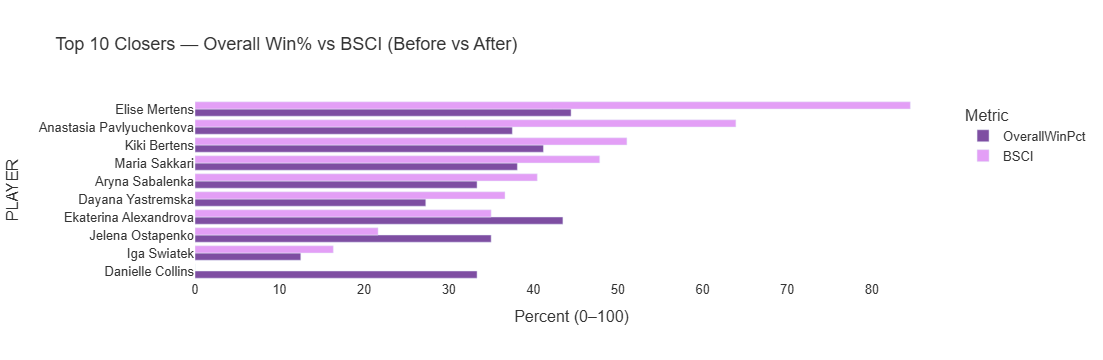

In [13]:
import plotly.express as px

top10 = (compare_valid.sort_values("BSCI", ascending=False)
         .head(10)
         .sort_values("BSCI", ascending=True))  # for left-to-right bar stack

melted = top10.melt(id_vars=["PLAYER"], value_vars=["OverallWinPct","BSCI"],
                    var_name="Metric", value_name="Value")

fig = px.bar(melted, x="Value", y="PLAYER", color="Metric", barmode="group",
             color_discrete_map={"OverallWinPct":"#7E4EA2","BSCI":"#E39FF6"},
             title="Top 10 Closers — Overall Win% vs BSCI (Before vs After)")
fig.update_layout(
    yaxis={"categoryorder":"array", "categoryarray": top10["PLAYER"].tolist()},
    xaxis_title="Percent (0–100)",
    legend_title="Metric",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(size=13, family="Arial", color="#333")
)
fig.show()


In [14]:
underrated = (compare_valid.sort_values("RankDelta_BSCI_minus_Overall")
              .head(8))[["PLAYER","OverallWinPct","BSCI","LateMatches","Rank_Overall","Rank_BSCI","RankDelta_BSCI_minus_Overall"]]
overrated  = (compare_valid.sort_values("RankDelta_BSCI_minus_Overall", ascending=False)
              .head(8))[["PLAYER","OverallWinPct","BSCI","LateMatches","Rank_Overall","Rank_BSCI","RankDelta_BSCI_minus_Overall"]]

print("Underrated by Overall (rise on BSCI):")
display(underrated)
print("\nOverrated by Overall (fall on BSCI):")
display(overrated)


Underrated by Overall (rise on BSCI):


,PLAYER,OverallWinPct,BSCI,LateMatches,Rank_Overall,Rank_BSCI,RankDelta_BSCI_minus_Overall
22,Anastasia Pavlyuchenkova,37.500000,63.917526,6.0,5.0,2.0,-3.0
101,Dayana Yastremska,27.272727,36.633663,6.0,9.0,6.0,-3.0
47,Aryna Sabalenka,33.333333,40.449438,10.0,7.0,5.0,-2.0
151,Iga Swiatek,12.500000,16.346154,6.0,10.0,9.0,-1.0
117,Elise Mertens,44.444444,84.536082,6.0,1.0,1.0,0.0
196,Kiki Bertens,41.176471,51.041667,6.0,3.0,3.0,0.0
236,Maria Sakkari,38.095238,47.826087,7.0,4.0,4.0,0.0
163,Jelena Ostapenko,35.000000,21.637427,10.0,6.0,8.0,2.0



Overrated by Overall (fall on BSCI):


,PLAYER,OverallWinPct,BSCI,LateMatches,Rank_Overall,Rank_BSCI,RankDelta_BSCI_minus_Overall
107,Ekaterina Alexandrova,43.478261,35.000000,6.0,2.0,7.0,5.0
94,Danielle Collins,33.333333,0.000000,6.0,7.0,10.0,3.0
163,Jelena Ostapenko,35.000000,21.637427,10.0,6.0,8.0,2.0
117,Elise Mertens,44.444444,84.536082,6.0,1.0,1.0,0.0
196,Kiki Bertens,41.176471,51.041667,6.0,3.0,3.0,0.0
236,Maria Sakkari,38.095238,47.826087,7.0,4.0,4.0,0.0
151,Iga Swiatek,12.500000,16.346154,6.0,10.0,9.0,-1.0
47,Aryna Sabalenka,33.333333,40.449438,10.0,7.0,5.0,-2.0


## Visual 2 — Before vs After: Overall vs Big-Stage Performance

We compare:
- Overall Singles Main-Draw win rate (all rounds)
- Big-Stage Close Rate (BSCI) in QF/SF/F

This chart supports the “before vs after” story in the report.


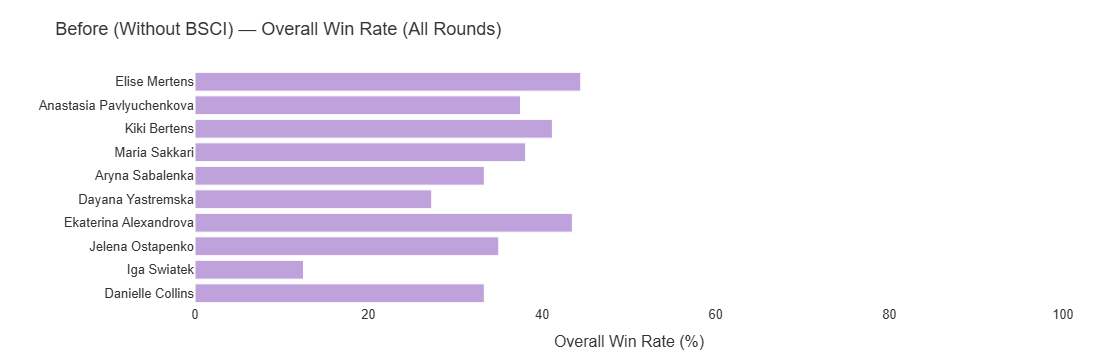

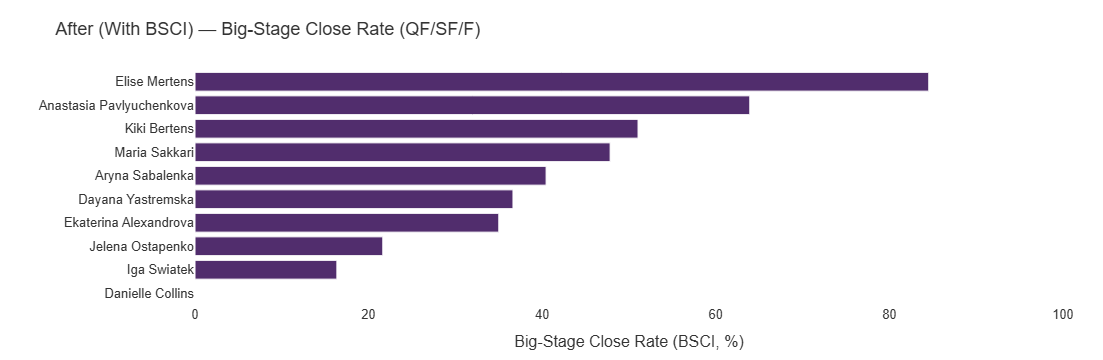

In [18]:
import pandas as pd
import plotly.express as px

# --- pick a consistent player set (union of top 10 by each metric) ---
top_overall = (compare_valid
               .sort_values("OverallWinPct", ascending=False)
               .head(10)["PLAYER"])
top_bsci    = (compare_valid
               .sort_values("BSCI", ascending=False)
               .head(10)["PLAYER"])

players = pd.Index(top_overall).union(pd.Index(top_bsci))
subset  = compare_valid[compare_valid["PLAYER"].isin(players)].copy()

# order y-axis by the AFTER metric (BSCI) so stories read left→right
order_by_bsci = (subset.sort_values("BSCI", ascending=True)["PLAYER"].tolist())

WTA_PURPLE = "#512D6D"
WTA_LILAC  = "#BFA2DB"

# --- BEFORE: Without BSCI (Overall Win %) ---
fig_before = px.bar(
    subset.sort_values("BSCI", ascending=True),  # just to keep same y order
    x="OverallWinPct", y="PLAYER",
    orientation="h",
    color_discrete_sequence=[WTA_LILAC],
    title="Before (Without BSCI) — Overall Win Rate (All Rounds)"
)
fig_before.update_layout(
    yaxis={"categoryorder":"array","categoryarray":order_by_bsci, "title":""},
    xaxis_title="Overall Win Rate (%)",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="Arial", size=13, color="#333"),
    margin=dict(l=160, r=40, t=70, b=50)
)
fig_before.update_traces(marker_line_color="white", marker_line_width=1)
fig_before.update_xaxes(range=[0,100])   # lock to 0–100 for apples-to-apples
fig_before.show()

# --- AFTER: With BSCI (Late Rounds Only) ---
fig_after = px.bar(
    subset.sort_values("BSCI", ascending=True),
    x="BSCI", y="PLAYER",
    orientation="h",
    color_discrete_sequence=[WTA_PURPLE],
    title="After (With BSCI) — Big-Stage Close Rate (QF/SF/F)"
)
fig_after.update_layout(
    yaxis={"categoryorder":"array","categoryarray":order_by_bsci, "title":""},
    xaxis_title="Big-Stage Close Rate (BSCI, %)",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="Arial", size=13, color="#333"),
    margin=dict(l=160, r=40, t=70, b=50)
)
fig_after.update_traces(marker_line_color="white", marker_line_width=1)
fig_after.update_xaxes(range=[0,100])    # same scale as BEFORE
fig_after.show()
